# Additional Analysis — Demographics, Subgroup Comparisons, and Post-hoc Power

Complementary analyses by grouping participants according to role, seniority, and experience. Includes demographic characterization, Q8 skill self-assessment, internal reliability, subgroup heatmaps, Mann-Whitney U + Cliff's delta, Spearman correlations, Fisher's exact tests for implementation questions, and post-hoc power analysis.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
imp_long = pd.read_csv(U.DATA_PROC / "likert_importance.csv")
pri_long = pd.read_csv(U.DATA_PROC / "likert_priority.csv")
skills_long = pd.read_csv(U.DATA_PROC / "skills.csv")
print(f"N={len(df)}")


N=56


In [2]:
# # projects: descriptive stats
proj = df["n_projects"]
proj_stats = pd.Series({
    "min": int(proj.min()),
    "Q1": float(proj.quantile(0.25)),
    "median": float(proj.median()),
    "Q3": float(proj.quantile(0.75)),
    "max": int(proj.max()),
    "mean": float(proj.mean()),
})
print("ML projects already participated in:")
print(proj_stats.round(1).to_string())

ML projects already participated in:
min        0.0
Q1         2.0
median     4.0
Q3         7.0
max       40.0
mean       6.4


## 11. Aggregated skills — % "Above average/Very high"

In [4]:
rng_add = np.random.default_rng(42)

def _boot_ci_likert(values: np.ndarray, n_bootstrap: int = 2000) -> tuple[float, float]:
    n = len(values)
    boot_props = np.mean(values[rng_add.integers(0, n, size=(n_bootstrap, n))] >= 4, axis=1)
    return np.percentile(boot_props, 2.5), np.percentile(boot_props, 97.5)

skill_pct = []
for col in U.SKILL_COLS:
    s = df[col].dropna()
    if len(s) == 0:
        continue
    lo, hi = _boot_ci_likert(s.values)
    skill_pct.append({
        "Activity": U.SKILL_LABELS_PT[col],
        "% High": (s >= 4).mean() * 100,
        "CI95": f"[{lo*100:.0f}-{hi*100:.0f}]",
        "n": int(len(s)),
    })
skill_pct_df = pd.DataFrame(skill_pct).sort_values("% High", ascending=False).reset_index(drop=True)
skill_pct_df.round(1)


,Activity,% High,CI95,n
0,Data cleaning,75.9,[65-87],54
1,Train/test split,72.7,[60-84],55
2,Normalization/standardization,68.5,[56-80],54
3,Outlier detection,63.0,[50-74],54
4,Source integration,63.0,[50-76],54
5,"Libraries (Pandas, etc.)",60.0,[47-73],55
6,Data validation,52.7,[40-67],55
7,Pipeline automation,47.2,[34-60],53
8,"Transformation (PCA, encoding)",46.3,[33-59],54
9,Production monitoring,33.3,[22-47],51


## 13. Internal reliability — Cronbach α and McDonald ω

Before treating Q11/Q13 as aggregated "constructs" (e.g., "% High Importance"),
we measure internal consistency of the blocks as Likert scales.

- **Cronbach α**: assumes tau-equivalence; pingouin returns a bootstrap 95% CI.
- **McDonald ω total**: 1-factor analysis on standardized items (`U.mcdonald_omega`); less sensitive to tau-equivalence violations.

Convention: α ≥ 0.7 acceptable, ≥ 0.8 good, ≥ 0.9 excellent (Nunnally 1978).


In [5]:
import pingouin as pg

def reliability_block(name: str, items: pd.DataFrame) -> dict:
    items = items.dropna()
    alpha, ci = pg.cronbach_alpha(data=items)
    omega = U.mcdonald_omega(items)
    return {"block": name, "n_subj": len(items), "k_items": items.shape[1],
            "cronbach_alpha": float(alpha),
            "alpha_ci_lo": float(ci[0]), "alpha_ci_hi": float(ci[1]),
            "mcdonald_omega": omega}

reli_imp = reliability_block("Q11 importance", df[U.IMP_COLS])
reli_pri = reliability_block("Q13 priority", df[U.PRI_COLS])
reli_skill = reliability_block("Q8 skills", df[U.SKILL_COLS])

reliability = pd.DataFrame([reli_imp, reli_pri, reli_skill])
print(reliability.to_string(index=False))
print()
for r in [reli_imp, reli_pri, reli_skill]:
    interp = (
        "excellent" if r["cronbach_alpha"] >= 0.9 else
        "good" if r["cronbach_alpha"] >= 0.8 else
        "acceptable" if r["cronbach_alpha"] >= 0.7 else
        "questionable" if r["cronbach_alpha"] >= 0.6 else
        "inadequate"
    )
    print(f"{r['block']}: α={r['cronbach_alpha']:.3f} "
          f"[{r['alpha_ci_lo']:.3f}, {r['alpha_ci_hi']:.3f}], "
          f"ω={r['mcdonald_omega']:.3f} — {interp} reliability.")


         block  n_subj  k_items  cronbach_alpha  alpha_ci_lo  alpha_ci_hi  mcdonald_omega
Q11 importance      56       13        0.905140        0.864        0.938        0.908007
  Q13 priority      56       13        0.892174        0.846        0.930        0.894550
     Q8 skills      49       10        0.919073        0.881        0.949        0.921662

Q11 importance: α=0.905 [0.864, 0.938], ω=0.908 — excellent reliability.
Q13 priority: α=0.892 [0.846, 0.930], ω=0.895 — good reliability.
Q8 skills: α=0.919 [0.881, 0.949], ω=0.922 — excellent reliability.


In [6]:
reliability.to_csv(TABLES / "reliability.csv", index=False)
print(f"-> tables/reliability.csv")
U.save_latex(
    reliability, "reliability",
    caption=(
        "Internal reliability of Q11, Q13, and Q8 Likert blocks. "
        "Cronbach $\alpha$ with 95\% bootstrap CI (pingouin); "
        "McDonald $\omega$ via single-factor extraction."
    ),
    label="tab:reliability",
)
print("[saved] tables/reliability.tex")

-> tables/reliability.csv
[saved] tables/reliability.tex


<>:7: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:8: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:8: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\kevin\AppData\Local\Temp\ipykernel_30480\448312472.py:7: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  "Cronbach $\alpha$ with 95\% bootstrap CI (pingouin); "
C:\Users\kevin\AppData\Local\Temp\ipykernel_30480\448312472.py:8: SyntaxWarning: "\o" is an invalid escape sequence. 

## 10. Heatmap subgroups × characteristics (% top-2)

Rows = subgroup, columns = characteristic, value = % "Important/Very important". Quickly highlights visual differences (Diversity Matters style).

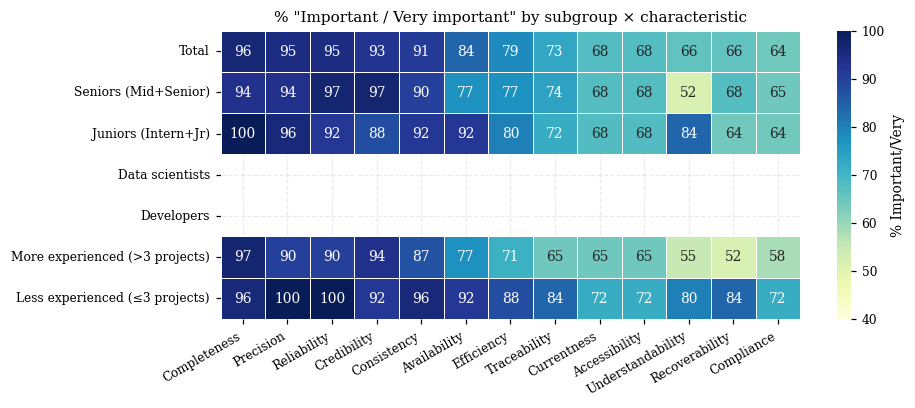

In [7]:
def pct_top2(df_sub: pd.DataFrame, col: str) -> float:
    s = df_sub[col].dropna()
    if len(s) == 0:
        return float("nan")
    return (s >= 4).sum() / len(s) * 100

groups = {
    "Total": df,
    "Seniors (Mid+Senior)": df[df["seniority_group"] == "senior"],
    "Juniors (Intern+Jr)": df[df["seniority_group"] == "junior"],
    "Data scientists": df[df["role_group"] == "data_scientist"],
    "Developers": df[df["role_group"] == "developer"],
    "More experienced (>3 projects)": df[df["n_projects"] > 3],
    "Less experienced (≤3 projects)": df[df["n_projects"] <= 3],
}

heat = pd.DataFrame(
    {label: [pct_top2(g, f"imp_{c}") for c in U.CHARACTERISTICS_PT.keys()] for label, g in groups.items()},
    index=[U.CHARACTERISTICS_PT[c] for c in U.CHARACTERISTICS_PT.keys()],
).T
# Sort columns by total %
heat = heat[heat.loc["Total"].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8.5, 3.4))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "% Important/Very"},
            linewidths=0.4, linecolor="white", ax=ax, vmin=40, vmax=100)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("% \"Important / Very important\" by subgroup × characteristic")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
U.save_fig(fig, "heatmap_importance_subgroups")
plt.show()

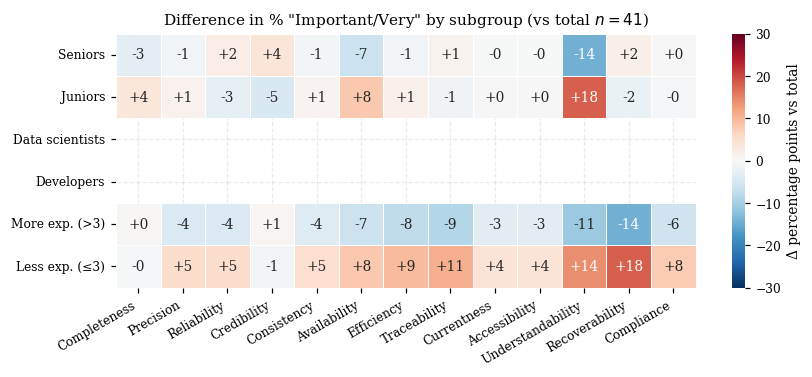

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
U.setup_matplotlib()

def pct_top2(g, col):
    s = g[col].dropna()
    return (s >= 4).sum() / len(s) * 100 if len(s) else np.nan

groups_def = {
    "Seniors": df[df["seniority_group"] == "senior"],
    "Juniors": df[df["seniority_group"] == "junior"],
    "Data scientists": df[df["role_group"] == "data_scientist"],
    "Developers": df[df["role_group"] == "developer"],
    "More exp. (>3)": df[df["n_projects"] > 3],
    "Less exp. (≤3)": df[df["n_projects"] <= 3],
}
total_imp = pd.Series({c: pct_top2(df, f"imp_{c}") for c in U.CHARACTERISTICS_PT.keys()})
diffs = pd.DataFrame({
    label: [pct_top2(g, f"imp_{c}") - total_imp[c] for c in U.CHARACTERISTICS_PT.keys()]
    for label, g in groups_def.items()
}, index=[U.CHARACTERISTICS_PT[c] for c in U.CHARACTERISTICS_PT.keys()]).T
diffs = diffs[total_imp.sort_values(ascending=False).rename(lambda c: U.CHARACTERISTICS_PT[c]).index]

fig, ax = plt.subplots(figsize=(8.5, 3.0))
sns.heatmap(diffs, annot=True, fmt="+.0f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Δ percentage points vs total"},
            linewidths=0.4, linecolor="white", ax=ax, vmin=-30, vmax=30)
ax.set_title("Difference in % \"Important/Very\" by subgroup (vs total $n=41$)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
U.save_fig(fig, "heatmap_subgroup_diff")
plt.show()

## 3. Significance Analysis and Effect Size

### 3.1 Helper: Mann–Whitney U + Cliff's Delta

Wraps `scipy.stats.mannwhitneyu` (two-sided) with Cliff's Delta and BCa bootstrap 95% CI.

In [10]:
def mwu_delta(g1: pd.Series, g2: pd.Series, n_boot: int = 10_000) -> dict:
    g1 = g1.dropna().astype(float)
    g2 = g2.dropna().astype(float)
    if len(g1) < 2 or len(g2) < 2:
        return {"U": np.nan, "p": np.nan, "delta": np.nan,
                "ci_lo": np.nan, "ci_hi": np.nan, "ci_method": "insufficient",
                "magnitude": "insufficient", "n1": len(g1), "n2": len(g2),
                "med1": np.nan, "med2": np.nan}
    U_stat, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    cd = U.cliffs_delta_with_ci(g1, g2, n_resamples=n_boot)
    return {"U": float(U_stat), "p": float(p),
            "delta": cd["delta"], "ci_lo": cd["ci_lo"], "ci_hi": cd["ci_hi"],
            "ci_method": cd["method"], "magnitude": cd["magnitude"],
            "n1": int(len(g1)), "n2": int(len(g2)),
            "med1": float(g1.median()), "med2": float(g2.median())}


Defines the 4 subgroup pairs and collects Mann–Whitney U + Cliff's Delta for each pair × each Likert column (importance and priority), totaling **4 × 13 × 2 = 104** tests.

In [11]:
comparisons = [
    ("Seniors × Juniors",
     df[df["seniority_group"] == "senior"], df[df["seniority_group"] == "junior"]),
    ("Data scientists × Developers",
     df[df["role_group"] == "data_scientist"], df[df["role_group"] == "developer"]),
    (">3 projects × ≤3 projects",
     df[df["n_projects"] > 3], df[df["n_projects"] <= 3]),
    ("Men × Women",
     df[df["gender_norm"] == "male"], df[df["gender_norm"] == "female"]),
]

def collect_tests(comparisons, cols, dim_label):
    rows = []
    for comp_name, g1, g2 in comparisons:
        for col in cols:
            char = col.split("_", 1)[1]
            r = mwu_delta(g1[col], g2[col])
            rows.append({"dim": dim_label, "comparison": comp_name,
                         "characteristic": char, **r})
    return pd.DataFrame(rows)

imp_tests = collect_tests(comparisons, U.IMP_COLS, "importance")
pri_tests = collect_tests(comparisons, U.PRI_COLS, "priority")
tests = pd.concat([imp_tests, pri_tests], ignore_index=True)
print(f"Total tests executed: {len(tests)}")

Total tests executed: 104


### 3.2 Holm–Bonferroni Correction

Applied **within each comparison-pair × dimension** (avoids over-correcting across unrelated comparisons).

In [12]:
def add_holm(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["p_holm"] = np.nan
    out["sig_raw"] = out["p"] < 0.05
    out["sig_holm"] = False
    for (comp, dim), grp in out.groupby(["comparison", "dim"]):
        valid = grp["p"].notna()
        if valid.sum() == 0:
            continue
        reject, p_adj, _, _ = multipletests(grp.loc[valid, "p"], method="holm")
        idx = grp.loc[valid].index
        out.loc[idx, "p_holm"] = p_adj
        out.loc[idx, "sig_holm"] = reject
    return out

tests = add_holm(tests)
sig_raw  = tests[tests["sig_raw"]]
sig_holm = tests[tests["sig_holm"]]
interesting = (tests[(tests["sig_raw"]) & (tests["delta"].abs() >= 0.33)]
               .sort_values("delta", key=abs, ascending=False))

print(f"Significant (raw p<0.05): {len(sig_raw)}")
print(f"Significant after Holm:   {len(sig_holm)}")



Significant (raw p<0.05): 15
Significant after Holm:   2


All significant tests

In [13]:
_disp_cols = ["dim", "comparison", "characteristic",
              "delta", "magnitude"]

display(
    interesting.loc[interesting["sig_holm"] == False, _disp_cols]
    .reset_index(drop=True)
)

,dim,comparison,characteristic,delta,magnitude
0,priority,Men × Women,credibility,-0.466667,medium
1,priority,>3 projects × ≤3 projects,efficiency,-0.400000,medium
2,priority,>3 projects × ≤3 projects,availability,-0.393548,medium
3,priority,Men × Women,recoverability,-0.391919,medium
4,priority,Men × Women,availability,-0.385859,medium
5,priority,>3 projects × ≤3 projects,compliance,-0.380645,medium
6,importance,Men × Women,availability,-0.359596,medium
7,importance,>3 projects × ≤3 projects,efficiency,-0.336774,medium
8,importance,>3 projects × ≤3 projects,recoverability,-0.330323,medium


Testes that passed holm

In [14]:
display(
    interesting.loc[interesting["sig_holm"] == True, _disp_cols]
    .reset_index(drop=True)
)

,dim,comparison,characteristic,delta,magnitude
0,priority,>3 projects × ≤3 projects,recoverability,-0.441290,medium
1,priority,>3 projects × ≤3 projects,reliability,-0.415484,medium


## 4. Spearman ρ — Correlation with n_projects and Seniority

Correlation ρ by characteristic between n_projects/seniority_ordinal and each Likert (Q11/Q13).

- **Paired bootstrap 95% CI** (BCa, 10k resamples; fallback to percentile if BCa degenerates).
- We report ρ [95% CI] in addition to p-value — more informative given N=41.


In [15]:
def spearman_rows(predictor: str, cols: list[str], dim: str,
                  n_boot: int = 10_000) -> pd.DataFrame:
    rows = []
    for col in cols:
        res = U.spearman_with_ci(df[predictor], df[col], n_resamples=n_boot)
        if res["method"] == "insufficient":
            continue
        rows.append({"dim": dim, "predictor": predictor,
                     "characteristic": col.split("_", 1)[1],
                     **res})
    return pd.DataFrame(rows)

spear = pd.concat([
    spearman_rows("n_projects", U.IMP_COLS, "importance"),
    spearman_rows("n_projects", U.PRI_COLS, "priority"),
    spearman_rows("seniority_ordinal", U.IMP_COLS, "importance"),
    spearman_rows("seniority_ordinal", U.PRI_COLS, "priority"),
], ignore_index=True)
spear["sig_raw"] = spear["p"] < 0.05
spear["ci_excludes_zero"] = (spear["ci_lo"] > 0) | (spear["ci_hi"] < 0)

print(f"Spearman: {len(spear)} tests")
print(f"Significant (raw p<0.05): {spear['sig_raw'].sum()}")
print(f"95% CI excludes zero:     {spear['ci_excludes_zero'].sum()}")
print(f"CI methods: {spear['method'].value_counts().to_dict()}")

Spearman: 52 tests
Significant (raw p<0.05): 8
95% CI excludes zero:     6
CI methods: {'bca': 52}


In [16]:
# spearman saves moved to c21_save (after Holm correction is applied)

holm correction

In [17]:
def add_holm_spearman(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["p_holm"] = np.nan
    out["sig_raw"] = out["p"] < 0.05
    out["sig_holm"] = False
    for (predictor, dim), grp in out.groupby(["predictor", "dim"]):
        valid = grp["p"].notna()
        if valid.sum() == 0:
            continue
        reject, p_adj, _, _ = multipletests(grp.loc[valid, "p"], method="holm")
        idx = grp.loc[valid].index
        out.loc[idx, "p_holm"] = p_adj
        out.loc[idx, "sig_holm"] = reject
    return out

spear = add_holm_spearman(spear)

print(f"Spearman: {len(spear)} tests")
print(f"Significant (raw p<0.05):    {spear['sig_raw'].sum()}")
print(f"Significant after Holm:      {spear['sig_holm'].sum()}")
print(f"95% CI excludes zero:        {spear['ci_excludes_zero'].sum()}")

interesting_spear = (spear[(spear["sig_raw"]) & (spear["rho"].abs() >= 0.3)]
                     .sort_values("rho", key=abs, ascending=False))

Spearman: 52 tests
Significant (raw p<0.05):    8
Significant after Holm:      2
95% CI excludes zero:        6


don't pass

In [18]:
_disp_cols = ["dim", "predictor", "characteristic", "n", "rho", "ci_lo", "ci_hi", "p", "p_holm", "sig_raw", "sig_holm", "method"]
display(
    spear[spear["sig_raw"]]
    .sort_values("rho", key=abs, ascending=False)
    [_disp_cols]
    .loc[lambda x: x["sig_holm"] == False]
    .reset_index(drop=True)
)

,dim,predictor,characteristic,n,rho,ci_lo,ci_hi,p,p_holm,sig_raw,sig_holm,method
0,priority,n_projects,reliability,56,-0.370049,-0.574938,-0.119209,0.004998,0.054983,True,False,bca
1,priority,n_projects,availability,56,-0.354891,-0.575373,-0.077135,0.007278,0.072784,True,False,bca
2,priority,n_projects,compliance,56,-0.294778,-0.528146,0.000683,0.027425,0.246821,True,False,bca
3,priority,n_projects,understandability,56,-0.285745,-0.512405,-0.012876,0.032775,0.262202,True,False,bca
4,importance,n_projects,efficiency,56,-0.276899,-0.510541,0.003054,0.038831,0.504807,True,False,bca
5,priority,seniority_ordinal,availability,56,-0.272123,-0.490858,-0.020741,0.042467,0.552067,True,False,bca


pass

In [19]:
_disp_cols = ["dim", "predictor", "characteristic", "n", "rho", "ci_lo", "ci_hi", "p", "p_holm", "sig_raw", "sig_holm", "method"]
display(
    spear[spear["sig_raw"]]
    .sort_values("rho", key=abs, ascending=False)
    [_disp_cols]
    .loc[lambda x: x["sig_holm"] == True]
    .reset_index(drop=True)
)

,dim,predictor,characteristic,n,rho,ci_lo,ci_hi,p,p_holm,sig_raw,sig_holm,method
0,priority,n_projects,efficiency,56,-0.453609,-0.648994,-0.213502,0.000446,0.005802,True,True,bca
1,priority,n_projects,recoverability,56,-0.382028,-0.600995,-0.107267,0.003667,0.044009,True,True,bca


## 8. Export: Consolidated Tables and Findings

### 8.1 Full Test Results and LaTeX Table

Includes **only** comparisons with p<0.05 or |delta|>=0.33 + small/medium/large magnitude. Maintains transparency: report everything in the replication package, cite only the relevant in the paper.

In [20]:
tests.to_csv(TABLES / "inferential_full.csv", index=False)
spear.to_csv(TABLES / "spearman_full.csv", index=False)
print(f"[saved] tables/inferential_full.csv ({len(tests)} rows)")
print(f"[saved] tables/spearman_full.csv ({len(spear)} rows)")

# LaTeX table only with non-negligible findings (|delta|>=0.33 OR sig)
report = tests[(tests["sig_raw"]) | (tests["delta"].abs() >= 0.33)].copy()
report = report.sort_values(["comparison", "dim", "p"]).reset_index(drop=True)

def format_p(p):
    if pd.isna(p):
        return "--"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

lines = [
    "\\begin{table*}[t]",
    "\\caption{Exploratory subgroup comparisons. Mann\u2013Whitney $U$, Cliff\u2019s $\\delta$ (Romano et al., 2006), $p_{\\text{Holm}}$ corrected by comparison pair. Only rows with $p<0.05$ or $|\\delta|\\geq 0.33$ shown.}",
    "\\label{tab:inferential}",
    "\\centering",
    "\\small",
    "\\begin{tabular}{llllrrlrll}",
    "\\toprule",
    "\\textbf{Comparison} & \\textbf{Dim.} & \\textbf{Characteristic} & \\textbf{Med.} & $\\delta$ & \\textbf{IC$_{95}$} & \\textbf{Mag.} & $U$ & $p$ & $p_{\\text{Holm}}$ \\\\",
    "\\midrule",
]
for _, r in report.iterrows():
    char = U.CHARACTERISTICS_PT.get(r["characteristic"], r["characteristic"])
    med_str = f"{r['med1']:.0f} vs {r['med2']:.0f}"
    lines.append(
        f"{r['comparison']} & {r['dim']} & {char} & {med_str} & {r['delta']:+.2f} & [{r['ci_lo']:+.2f},{r['ci_hi']:+.2f}] & {r['magnitude']} & {r['U']:.0f} & {format_p(r['p'])} & {format_p(r['p_holm'])} \\\\"
    )
lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table*}"])
(TABLES / "inferential.tex").write_text("\n".join(lines), encoding="utf-8")
print(f"[saved] tables/inferential.tex ({len(report)} rows in paper)")

# Holm-filtered saves
mwu_holm = tests[tests["sig_holm"] == True].reset_index(drop=True)
mwu_holm.to_csv(TABLES / "inferential_holm_sig.csv", index=False)
print(f"[saved] tables/inferential_holm_sig.csv ({len(mwu_holm)} rows)")

spear_holm = spear[spear["sig_holm"] == True].reset_index(drop=True)
spear_holm.to_csv(TABLES / "spearman_holm_sig.csv", index=False)
print(f"[saved] tables/spearman_holm_sig.csv ({len(spear_holm)} rows)")

# LaTeX tables
U.save_latex(
    tests, "inferential_full",
    caption=(
        "Mann--Whitney $U$ + Cliff's $\delta$ subgroup comparisons "
        "(full, $4 \times 13 \times 2 = 104$ tests). "
        "Holm--Bonferroni correction within each comparison pair $\times$ dimension."
    ),
    label="tab:mwu-full",
)
print("[saved] tables/inferential_full.tex")

U.save_latex(
    mwu_holm, "inferential_holm_sig",
    caption="Subgroup comparisons surviving Holm--Bonferroni correction.",
    label="tab:mwu-holm",
)
print("[saved] tables/inferential_holm_sig.tex")

U.save_latex(
    spear, "spearman_full",
    caption=(
        "Spearman $\rho$ correlations: n\_projects and seniority vs Likert ratings (Q11/Q13). "
        "BCa 95\% CI, 10k resamples; Holm--Bonferroni correction within predictor $\times$ dimension."
    ),
    label="tab:spearman-full",
)
print("[saved] tables/spearman_full.tex")

U.save_latex(
    spear_holm, "spearman_holm_sig",
    caption="Spearman $\rho$ -- associations surviving Holm--Bonferroni correction ($\alpha=0.05$).",
    label="tab:spearman-holm",
)
print("[saved] tables/spearman_holm_sig.tex")

[saved] tables/inferential_full.csv (104 rows)
[saved] tables/spearman_full.csv (52 rows)
[saved] tables/inferential.tex (17 rows in paper)
[saved] tables/inferential_holm_sig.csv (2 rows)
[saved] tables/spearman_holm_sig.csv (2 rows)
[saved] tables/inferential_full.tex
[saved] tables/inferential_holm_sig.tex
[saved] tables/spearman_full.tex
[saved] tables/spearman_holm_sig.tex


<>:51: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:69: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:70: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:51: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:69: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:70: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
C:\Users\kevin\AppData\Local\Temp\ipykernel_30480\670184451.py:51: SyntaxWar

In [21]:
_disp_cols = ["comparison", "dim", "characteristic", "med1", "med2",
              "delta", "magnitude", "p", "p_holm"]
display(report[_disp_cols])

,comparison,dim,characteristic,med1,med2,delta,magnitude,p,p_holm
0,>3 projects × ≤3 projects,importance,efficiency,4.0,4.0,-0.336774,medium,0.019953,0.259389
1,>3 projects × ≤3 projects,importance,recoverability,4.0,5.0,-0.330323,medium,0.024926,0.299110
2,>3 projects × ≤3 projects,importance,reliability,5.0,5.0,-0.270968,small,0.037909,0.416997
3,>3 projects × ≤3 projects,priority,recoverability,3.0,4.0,-0.441290,medium,0.003151,0.040961
4,>3 projects × ≤3 projects,priority,reliability,4.0,5.0,-0.415484,medium,0.003625,0.043503
5,>3 projects × ≤3 projects,priority,efficiency,3.0,4.0,-0.400000,medium,0.007531,0.082837
6,>3 projects × ≤3 projects,priority,availability,4.0,4.0,-0.393548,medium,0.008134,0.082837
7,>3 projects × ≤3 projects,priority,compliance,3.0,5.0,-0.380645,medium,0.010949,0.098541
8,>3 projects × ≤3 projects,priority,understandability,3.0,4.0,-0.299355,small,0.045707,0.365653
9,Men × Women,importance,availability,4.0,5.0,-0.359596,medium,0.044651,0.580464


### 8.2 Inferential Summary — Plug-and-Play Text

In [22]:
# Concise text findings
report_text = []
if len(sig_holm):
    for _, r in sig_holm.iterrows():
        char = U.CHARACTERISTICS_PT.get(r["characteristic"], r["characteristic"])
        report_text.append(
            f"[{r['comparison']}, {r['dim']}] {char}: "
            f"$\\delta$={r['delta']:+.2f} ({r['magnitude']}), p={r['p']:.3f}, p_Holm={r['p_holm']:.3f}."
        )
else:
    report_text.append("No comparison survived Holm correction. Report as exploratory.")

for _, r in interesting.iterrows():
    if not r['sig_holm']:
        char = U.CHARACTERISTICS_PT.get(r["characteristic"], r["characteristic"])
        report_text.append(
            f"[{r['comparison']}, {r['dim']}] {char}: "
            f"$\\delta$={r['delta']:+.2f} ({r['magnitude']}), p={r['p']:.3f} raw (did not survive Holm) — report as a trend."
        )

(TABLES / "inferential_findings.txt").write_text("\n".join(report_text), encoding="utf-8")
print(f"[saved] tables/inferential_findings.txt ({len(report_text)} lines)")

[saved] tables/inferential_findings.txt (11 lines)


In [23]:
display(
    pd.DataFrame({"finding": report_text})
)

,finding
0,"[>3 projects × ≤3 projects, priority] Reliabil..."
1,"[>3 projects × ≤3 projects, priority] Recovera..."
2,"[Men × Women, priority] Credibility: $\delta$=..."
3,"[>3 projects × ≤3 projects, priority] Efficien..."
4,"[>3 projects × ≤3 projects, priority] Availabi..."
5,"[Men × Women, priority] Recoverability: $\delt..."
6,"[Men × Women, priority] Availability: $\delta$..."
7,"[>3 projects × ≤3 projects, priority] Complian..."
8,"[Men × Women, importance] Availability: $\delt..."
9,"[>3 projects × ≤3 projects, importance] Effici..."


## Fisher's Exact — Q17–Q21 × Demographic Subgroups

For each binary checkbox item (presence/absence), tests association with: Seniors × Juniors, Data scientists × Developers, Men × Women.

In [24]:
Q17_OPTIONS = {
    "q17_initial_eval": [
        "Avaliação inicial durante a coleta e preparação de dados",
        "Initial assessment during data collection and preparation",
    ],
    "q17_continuous_mon": [
        "Monitoramento contínuo durante todo o ciclo de vida do modelo",
        "Continuous monitoring throughout the model's life cycle",
    ],
    "q17_test_sets": [
        "Conjuntos de testes são aplicados para validar a consistência, completude e precisão dos dados antes de serem usados no treinamento.",
        "Test sets are applied to validate the consistency, completeness and accuracy of the data before it is used for training.",
    ],
    "q17_no_strategy": [
        "Não existe uma estratégia formal para assegurar a qualidade dos dados durante o desenvolvimento.",
        "There is no formal strategy to ensure data quality during development.",
    ],
}
Q17_LABELS = {
    "q17_initial_eval": "Initial assessment in collection/preparation",
    "q17_continuous_mon": "Continuous monitoring across lifecycle",
    "q17_test_sets": "Test sets before training",
    "q17_no_strategy": "No formal strategy",
}
Q18_OPTIONS = {
    "q18_ab_tests": ["Testes A/B", "A/B testing"],
    "q18_perf_metrics": [
        "Análise de métricas de performance (ex.: precisão, recall)",
        "Analysis of performance metrics (e.g. precision, recall)",
    ],
    "q18_manual_review": ["Revisão manual dos resultados", "Manual review of results"],
}
Q18_LABELS = {
    "q18_ab_tests": "A/B testing",
    "q18_perf_metrics": "Performance metrics",
    "q18_manual_review": "Manual review of results",
}
Q20_OPTIONS = {
    "q20_structured_text": ["Linguagem estruturada (texto)", "Structured language (text)"],
    "q20_pm_tools": [
        "Ferramentas de Gerenciamento de Projetos (Jira, Trello ou Asana)",
        "Project management tools (Jira, Trello or Asana)",
    ],
    "q20_central_docs": [
        "Documentação Centralizada (Sistemas como Confluence, Google Docs ou Notion)",
        "Centralized documentation (systems such as Confluence, Google Docs or Notion)",
    ],
    "q20_alignment_meet": ["Reuniões de Alinhamento", "Alignment meetings"],
    "q20_periodic_reports": ["Relatórios Periódicos", "Periodic reports"],
}
Q20_LABELS = {
    "q20_structured_text": "Structured language (text)",
    "q20_pm_tools": "Project management tools (Jira/etc.)",
    "q20_central_docs": "Centralized documentation (Confluence/etc.)",
    "q20_alignment_meet": "Alignment meetings",
    "q20_periodic_reports": "Periodic reports",
}
Q21_OPTIONS = {
    "q21_inconsistency": [
        "Inconsistência entre diferentes fontes de dados",
        "Inconsistency between different data sources",
    ],
    "q21_incompleteness": ["Dados incompletos ou ausentes", "Incomplete or missing data"],
    "q21_no_standard": [
        "Falta de padronização nos formatos de dados",
        "Lack of standardization in data formats",
    ],
    "q21_outdated": ["Dados desatualizados ou não confiáveis", "Outdated or unreliable data"],
    "q21_collection_errors": [
        "Erros introduzidos durante a coleta e processamento",
        "Errors introduced during collection and processing",
    ],
    "q21_traceability": [
        "Dificuldade na rastreabilidade e versionamento dos dados",
        "Difficulty in data traceability and versioning",
    ],
    "q21_no_tools": [
        "Falta de ferramentas adequadas para validação da qualidade dos dados",
        "Lack of adequate tools for validating data quality",
    ],
}
Q21_LABELS = {
    "q21_inconsistency": "Inconsistency across sources",
    "q21_incompleteness": "Incomplete/missing data",
    "q21_no_standard": "Lack of format standardization",
    "q21_outdated": "Outdated/unreliable data",
    "q21_collection_errors": "Errors in collection and processing",
    "q21_traceability": "Difficulty in traceability/versioning",
    "q21_no_tools": "Lack of validation tools",
}


In [25]:
rng_ck = np.random.default_rng(42)

def _boot_ci_bin(values, n_bootstrap=2000, ci_level=0.95):
    values = np.asarray(values)
    n = len(values)
    if n == 0:
        return float("nan"), float("nan")
    alpha = 1 - ci_level
    boot_indices = rng_ck.integers(0, n, size=(n_bootstrap, n))
    boot_props = np.mean(values[boot_indices] >= 1, axis=1)
    return np.percentile(boot_props, 100 * alpha / 2), np.percentile(boot_props, 100 * (1 - alpha / 2))

def parse_checkboxes(series, options):
    binary = pd.DataFrame(index=series.index, columns=list(options.keys()), dtype=bool)
    binary[:] = False
    residual = series.copy()
    for key, raw in options.items():
        labels_list = [raw] if isinstance(raw, str) else list(raw)
        present = pd.Series(False, index=series.index)
        for lab in labels_list:
            present = present | series.fillna("").str.contains(lab, regex=False)
            residual = residual.fillna("").str.replace(lab, "", regex=False)
        binary[key] = present
    residual = residual.str.replace(r"^[,\.\s]+|[,\.\s]+$", "", regex=True)
    residual = residual.where(residual.str.len() > 2, "")
    return binary, residual

def proportions_with_ci(binary, labels, n_total):
    rows = []
    for key in binary.columns:
        vals = binary[key].astype(int).values
        lo, hi = _boot_ci_bin(vals)
        rows.append({
            "key": key, "label": labels[key],
            "n": int(binary[key].sum()),
            "pct": binary[key].mean() * 100,
            "ci_lo": lo * 100, "ci_hi": hi * 100,
        })
    return pd.DataFrame(rows).sort_values("pct", ascending=False).reset_index(drop=True)

q17_bin, _ = parse_checkboxes(df["incorporation_open"], Q17_OPTIONS)
q18_bin, _ = parse_checkboxes(df["measurement_open"], Q18_OPTIONS)
q20_bin, _ = parse_checkboxes(df["documentation_open"], Q20_OPTIONS)
q21_bin, _ = parse_checkboxes(df["challenges_open"], Q21_OPTIONS)

n_q17 = df["incorporation_open"].notna().sum()
n_q18 = df["measurement_open"].notna().sum()
n_q20 = df["documentation_open"].notna().sum()
n_q21 = df["challenges_open"].notna().sum()

p17 = proportions_with_ci(q17_bin, Q17_LABELS, n_q17)
p18 = proportions_with_ci(q18_bin, Q18_LABELS, n_q18)
p20 = proportions_with_ci(q20_bin, Q20_LABELS, n_q20)
p21 = proportions_with_ci(q21_bin, Q21_LABELS, n_q21)

all_bin = pd.concat([q17_bin, q18_bin, q20_bin, q21_bin], axis=1)
all_bin.to_csv(U.DATA_PROC / "checkboxes.csv", index_label="respondent_id")
print(f"[saved] data/processed/checkboxes.csv — {all_bin.shape}")


[saved] data/processed/checkboxes.csv — (56, 19)


## 9. Fisher's exact — Q17/Q18/Q20/Q21 × demographic subgroups

For each binary marked item (presence/absence), tests association with:
- Seniors × Juniors
- Data scientists × Developers
- Men × Women

Why Fisher and not χ²: 2×2 tables with cells < 5 are common at N=41; Fisher's exact is exact under H0.

- Effect size: odds ratio (95% Wald CI on log-OR; continuity correction +0.5 when a cell is zero).
- Holm–Bonferroni within each family (question × comparison).


In [26]:
from statsmodels.stats.multitest import multipletests

# The binary dataframes (q17_bin etc) share the same index as df
binaries = [
    ("Q17", q17_bin, Q17_LABELS, df["incorporation_open"]),
    ("Q18", q18_bin, Q18_LABELS, df["measurement_open"]),
    ("Q20", q20_bin, Q20_LABELS, df["documentation_open"]),
    ("Q21", q21_bin, Q21_LABELS, df["challenges_open"]),
]

comparisons = [
    ("Seniors × Juniors", df["seniority_group"] == "senior", df["seniority_group"] == "junior"),
    ("Data scientists × Developers", df["role_group"] == "data_scientist", df["role_group"] == "developer"),
    ("Men × Women", df["gender_norm"] == "male", df["gender_norm"] == "female"),
]

rows = []
for q_name, bin_df, labels, source in binaries:
    answered = source.notna()
    for comp_name, mask_g1, mask_g2 in comparisons:
        m1 = answered & mask_g1
        m2 = answered & mask_g2
        if m1.sum() < 3 or m2.sum() < 3:
            continue
        for col in bin_df.columns:
            a = int(bin_df.loc[m1, col].sum())
            c = int(m1.sum() - a)
            b = int(bin_df.loc[m2, col].sum())
            d = int(m2.sum() - b)
            if (a + b) == 0 or (c + d) == 0:
                continue
            res = U.fisher_or_ci(a, b, c, d)
            rows.append({"question": q_name, "comparison": comp_name,
                         "item": labels.get(col, col),
                         "a": a, "b": b, "c": c, "d": d,
                         **res})

fisher_df = pd.DataFrame(rows)

# Holm within each (question, comparison)
fisher_df["p_holm"] = float("nan")
fisher_df["sig_holm"] = False
for (q, comp), grp in fisher_df.groupby(["question", "comparison"]):
    valid = grp["p"].notna()
    if valid.sum() == 0:
        continue
    reject, p_adj, _, _ = multipletests(grp.loc[valid, "p"], method="holm")
    idx = grp.loc[valid].index
    fisher_df.loc[idx, "p_holm"] = p_adj
    fisher_df.loc[idx, "sig_holm"] = reject
fisher_df["sig_raw"] = fisher_df["p"] < 0.05

print(f"Fisher: {len(fisher_df)} tests")
print(f"Significant (raw p<0.05): {fisher_df['sig_raw'].sum()}")
print(f"Significant after Holm:    {fisher_df['sig_holm'].sum()}")
print()
disp = ["question", "comparison", "item", "n1", "n2", "p1", "p2", "or", "or_lo", "or_hi", "p", "p_holm"]
print("Significant (raw):")
sig = fisher_df[fisher_df["sig_raw"]].sort_values("p")
if len(sig):
    print(sig[disp].to_string(index=False))
else:
    print("  (none)")

Fisher: 38 tests
Significant (raw p<0.05): 3
Significant after Holm:    0

Significant (raw):
question  comparison                                  item  n1  n2       p1       p2       or    or_lo    or_hi        p   p_holm
     Q21 Men × Women              Lack of validation tools  45  11 0.311111 0.727273 0.169355 0.038964 0.736082 0.016799 0.117590
     Q21 Men × Women Difficulty in traceability/versioning  45  11 0.177778 0.545455 0.180180 0.043921 0.739172 0.019979 0.119875
     Q20 Men × Women  Project management tools (Jira/etc.)  45  11 0.377778 0.727273 0.227679 0.053016 0.977768 0.047756 0.238778


In [27]:
# Save full table for inspection
out = TABLES / "fisher_checkboxes.csv"
out.parent.mkdir(parents=True, exist_ok=True)
fisher_df.to_csv(out, index=False)
print(f"-> {out.relative_to(U.ROOT)} ({len(fisher_df)} rows)")

fisher_holm = fisher_df[fisher_df["sig_holm"] == True].reset_index(drop=True)
fisher_holm.to_csv(TABLES / "fisher_holm_sig.csv", index=False)
print(f"[saved] tables/fisher_holm_sig.csv ({len(fisher_holm)} rows)")

U.save_latex(
    fisher_df, "fisher_checkboxes",
    caption=(
        "Fisher's exact tests: Q17--Q21 binary items vs demographic subgroups. "
        "Odds ratio with Wald 95\% CI; Holm--Bonferroni correction within (question, comparison)."
    ),
    label="tab:fisher-full",
)
print("[saved] tables/fisher_checkboxes.tex")

U.save_latex(
    fisher_holm, "fisher_holm_sig",
    caption="Q17--Q21 Fisher tests surviving Holm--Bonferroni correction ($\alpha=0.05$).",
    label="tab:fisher-holm",
)
print("[saved] tables/fisher_holm_sig.tex")

-> data\processed\tables\fisher_checkboxes.csv (38 rows)
[saved] tables/fisher_holm_sig.csv (0 rows)
[saved] tables/fisher_checkboxes.tex
[saved] tables/fisher_holm_sig.tex


<>:15: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:15: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
C:\Users\kevin\AppData\Local\Temp\ipykernel_30480\3000905805.py:15: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  "Odds ratio with Wald 95\% CI; Holm--Bonferroni correction within (question, comparison)."


## 8. Key findings for findings boxes

In [29]:
# Most and least adopted practices
print("--- Q17 incorporation ---")
print(f"  Most common: {p17.iloc[0]['label']} ({p17.iloc[0]['pct']:.0f}%)")
print(f"  No formal strategy: {p17[p17['key']=='q17_no_strategy']['pct'].iloc[0]:.0f}%")

print("--- Q18 measurement ---")
print(f"  Most common: {p18.iloc[0]['label']} ({p18.iloc[0]['pct']:.0f}%)")
print(f"  A/B testing: {p18[p18['key']=='q18_ab_tests']['pct'].iloc[0]:.0f}%")

print("--- Q20 documentation ---")
print(f"  Most common: {p20.iloc[0]['label']} ({p20.iloc[0]['pct']:.0f}%)")
print(f"  Periodic reports: {p20[p20['key']=='q20_periodic_reports']['pct'].iloc[0]:.0f}%")

print("--- Q21 challenges ---")
for _, r in p21.head(3).iterrows():
    print(f"  {r['label']}: {r['pct']:.0f}% (IC95 {r['ci_lo']:.0f}–{r['ci_hi']:.0f})")

--- Q17 incorporation ---
  Most common: Initial assessment in collection/preparation (75%)
  No formal strategy: 12%
--- Q18 measurement ---
  Most common: Performance metrics (93%)
  A/B testing: 29%
--- Q20 documentation ---
  Most common: Alignment meetings (73%)
  Periodic reports: 20%
--- Q21 challenges ---
  Incomplete/missing data: 70% (IC95 57–80)
  Inconsistency across sources: 62% (IC95 50–75)
  Outdated/unreliable data: 50% (IC95 38–62)


## Combined LaTeX Table (Q17–Q21) — implementation.tex

## 5. Consolidated LaTeX table (Q17/Q18/Q20/Q21)

In [30]:
def render_latex(p: pd.DataFrame, label: str, n: int) -> list[str]:
    header = "\\multicolumn{4}{l}{\\textit{" + label + f" (n={n})" + "}} \\\\"
    out = [header]
    for _, r in p.iterrows():
        out.append(f"\\quad {r['label']} & {int(r['n'])} & {r['pct']:.0f}\\% & [{r['ci_lo']:.0f}--{r['ci_hi']:.0f}] \\\\")
    return out

lines = [
    "\\begin{table}[t]",
    "\\caption{Practices for incorporation, measurement, documentation, and perceived challenges. Proportions with Wilson 95\\% CI.}",
    "\\label{tab:implementation}",
    "\\centering",
    "\\small",
    "\\begin{tabular}{lrrr}",
    "\\toprule",
    "\\textbf{Item} & \\textbf{n} & \\textbf{\\%} & \\textbf{IC 95\\%} \\\\",
    "\\midrule",
]
lines.extend(render_latex(p17, "Q17. Incorporation into development", n_q17))
lines.append("\\midrule")
lines.extend(render_latex(p18, "Q18. Measurement of model impact", n_q18))
lines.append("\\midrule")
lines.extend(render_latex(p20, "Q20. Documentation and communication", n_q20))
lines.append("\\midrule")
lines.extend(render_latex(p21, "Q21. Challenges to ensure reliability", n_q21))
lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table}"])
(TABLES / "implementation.tex").write_text("\n".join(lines))
print("[saved] tables/implementation.tex")

[saved] tables/implementation.tex


# 05 — Robustness and Statistical Power Analysis (post-hoc)

This notebook answers: **given N=41 and the subgroup splits, what is the minimum
detectable effect (MDE) with α=0.05 and power=80%?**

Traditional G*Power assumes normal distributions; here we simulate under the test we
actually use (Mann–Whitney U) and on a 1-5 Likert scale — more transparent.

**Methodology (Monte Carlo):**
1. For each candidate δ ∈ \[0.05, 0.85\], convert to shift on the latent normal
   scale via δ = 2·Φ(d/√2) − 1.
2. Generate N1 latent values ~ N(d, 1), N2 values ~ N(0, 1).
3. Discretize into 5-level Likert via cuts at the standard quantiles (-1.28, -0.52, 0.52, 1.28).
4. Run two-sided MWU; record p < 0.05.
5. Repeat `n_reps` times; power = fraction of rejections.
6. MDE = smallest δ with power ≥ 0.8.


## 1. Power simulation function


In [31]:
# Likert cuts: symmetric on the standard normal for 5 categories with masses ~ (10, 25, 30, 25, 10)%
LIKERT_CUTS = np.array([-1.282, -0.524, 0.524, 1.282])

def discretize_likert(z: np.ndarray) -> np.ndarray:
    return np.searchsorted(LIKERT_CUTS, z) + 1  # 1..5

def delta_to_shift(delta: float) -> float:
    """δ = 2·Φ(d/√2) − 1  ⇒  d = √2 · Φ⁻¹((δ+1)/2)."""
    return float(np.sqrt(2) * stats.norm.ppf((delta + 1) / 2))

def simulate_power(n1: int, n2: int, delta: float, n_reps: int = 2000,
                   alpha: float = 0.05, rng=None) -> float:
    if rng is None:
        rng = np.random.default_rng()
    d = delta_to_shift(delta)
    rejections = 0
    for _ in range(n_reps):
        x = rng.normal(d, 1.0, size=n1)
        y = rng.normal(0.0, 1.0, size=n2)
        x_l = discretize_likert(x)
        y_l = discretize_likert(y)
        try:
            p = stats.mannwhitneyu(x_l, y_l, alternative="two-sided").pvalue
        except ValueError:
            p = 1.0
        if p < alpha:
            rejections += 1
    return rejections / n_reps

# Sanity check
p0 = simulate_power(20, 12, delta=0.0, n_reps=1000, rng=np.random.default_rng(7))
print(f"δ=0 (H0): power ≈ {p0:.3f} (expected ≈ 0.05)")


δ=0 (H0): power ≈ 0.047 (expected ≈ 0.05)


## 2. Power curves by subgroup


In [32]:
splits = [
    ("Seniors × Juniors", 20, 12),
    ("Data scientists × Developers", 18, 10),
    (">3 projects × ≤3 projects", 17, 15),
    ("Men × Women", 24, 8),
    ("Paired N=41",       41, 41),  # ref Wilcoxon — same n
]

deltas = np.round(np.arange(0.05, 0.86, 0.05), 2)
n_reps = 2000

power_rows = []
for label, n1, n2 in splits:
    for d in deltas:
        pw = simulate_power(n1, n2, d, n_reps=n_reps, rng=np.random.default_rng(42))
        power_rows.append({"split": label, "n1": n1, "n2": n2, "delta": d, "power": pw})

power_df = pd.DataFrame(power_rows)
print(power_df.head())


               split  n1  n2  delta   power
0  Seniors × Juniors  20  12   0.05  0.0465
1  Seniors × Juniors  20  12   0.10  0.0640
2  Seniors × Juniors  20  12   0.15  0.0985
3  Seniors × Juniors  20  12   0.20  0.1460
4  Seniors × Juniors  20  12   0.25  0.2050


In [33]:
# MDE per split (smallest δ with power ≥ 0.8)
mde_rows = []
for label in power_df["split"].unique():
    sub = power_df[power_df["split"] == label].sort_values("delta")
    above = sub[sub["power"] >= 0.80]
    if len(above):
        mde = float(above.iloc[0]["delta"])
        achieved = float(above.iloc[0]["power"])
    else:
        mde = float("nan")
        achieved = float(sub["power"].max())
    mde_rows.append({"split": label,
                     "n1": int(sub.iloc[0]["n1"]),
                     "n2": int(sub.iloc[0]["n2"]),
                     "MDE_delta_p80": mde,
                     "MDE_magnitude": U.classify_cliffs_delta(mde) if mde == mde else "—",
                     "max_power_observed": achieved})

mde_df = pd.DataFrame(mde_rows)
print("=== Minimum detectable effect (power ≥ 0.8, α=0.05) ===")
print(mde_df.to_string(index=False))


=== Minimum detectable effect (power ≥ 0.8, α=0.05) ===
                       split  n1  n2  MDE_delta_p80 MDE_magnitude  max_power_observed
           Seniors × Juniors  20  12           0.60         large              0.8305
Data scientists × Developers  18  10           0.65         large              0.8470
   >3 projects × ≤3 projects  17  15           0.60         large              0.8550
                 Men × Women  24   8           0.65         large              0.8150
                 Paired N=41  41  41           0.40        medium              0.8870


## 3. Plot — power curves by subgroup


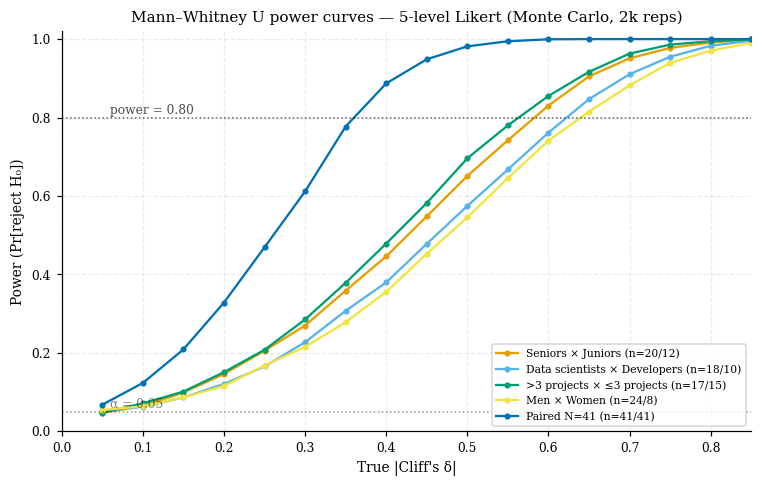

In [34]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))
for i, label in enumerate(power_df["split"].unique()):
    sub = power_df[power_df["split"] == label].sort_values("delta")
    color = U.PALETTE_WONG[(i + 1) % len(U.PALETTE_WONG)]
    ax.plot(sub["delta"], sub["power"], marker="o", markersize=3,
            color=color, linewidth=1.5, label=f"{label} (n={sub.iloc[0]['n1']}/{sub.iloc[0]['n2']})")

ax.axhline(0.80, color="black", linestyle=":", linewidth=1, alpha=0.6)
ax.text(0.06, 0.81, "power = 0.80", fontsize=8, color="black", alpha=0.7)
ax.axhline(0.05, color="black", linestyle=":", linewidth=1, alpha=0.4)
ax.text(0.06, 0.06, "α = 0.05", fontsize=8, color="black", alpha=0.5)

ax.set_xlabel("True |Cliff's δ|")
ax.set_ylabel("Power (Pr[reject H₀])")
ax.set_title("Mann–Whitney U power curves — 5-level Likert (Monte Carlo, 2k reps)")
ax.set_xlim(0, 0.85)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right", fontsize=7)
fig.tight_layout()
U.save_fig(fig, "power_curves")
plt.show()


## 4. Save tables


In [35]:
power_df.to_csv(TABLES / "power_simulation.csv", index=False)
mde_df.to_csv(TABLES / "mde_per_split.csv", index=False)
print("-> tables/power_simulation.csv, tables/mde_per_split.csv")
print("-> figures/power_curves.pdf")
U.save_latex(
    mde_df, "mde_per_split",
    caption=(
        "Minimum detectable effect (MDE) at 80\% power by subgroup split "
        "(Monte Carlo MWU, 5-level Likert, $\alpha=0.05$, 2k replicates)."
    ),
    label="tab:mde",
)
print("[saved] tables/mde_per_split.tex")

-> tables/power_simulation.csv, tables/mde_per_split.csv
-> figures/power_curves.pdf
[saved] tables/mde_per_split.tex


<>:8: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:8: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
C:\Users\kevin\AppData\Local\Temp\ipykernel_30480\3047012694.py:8: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  "Minimum detectable effect (MDE) at 80\% power by subgroup split "


## 5. Plug-and-play text for Threats to Validity

Typical conclusion for the paper (auto-generated after execution):


In [36]:
lines = ["**Post-hoc sensitivity analysis (Monte Carlo, MWU on 5-level Likert):**"]
for _, r in mde_df.iterrows():
    if r["MDE_delta_p80"] == r["MDE_delta_p80"]:
        lines.append(
            f"- *{r['split']}* (n={r['n1']}/{r['n2']}): "
            f"MDE = |δ| ≥ {r['MDE_delta_p80']:.2f} ({r['MDE_magnitude']}); "
            f"effects below this threshold have power < 80%."
        )
    else:
        lines.append(
            f"- *{r['split']}* (n={r['n1']}/{r['n2']}): even |δ|=0.85 only reaches "
            f"power = {r['max_power_observed']:.2f} — split is severely underpowered."
        )
print("\n".join(lines))


**Post-hoc sensitivity analysis (Monte Carlo, MWU on 5-level Likert):**
- *Seniors × Juniors* (n=20/12): MDE = |δ| ≥ 0.60 (large); effects below this threshold have power < 80%.
- *Data scientists × Developers* (n=18/10): MDE = |δ| ≥ 0.65 (large); effects below this threshold have power < 80%.
- *>3 projects × ≤3 projects* (n=17/15): MDE = |δ| ≥ 0.60 (large); effects below this threshold have power < 80%.
- *Men × Women* (n=24/8): MDE = |δ| ≥ 0.65 (large); effects below this threshold have power < 80%.
- *Paired N=41* (n=41/41): MDE = |δ| ≥ 0.40 (medium); effects below this threshold have power < 80%.
